# A/B Test Analysis: Marketing Campaign Landing Page

**Business decision:** Should the company **ship** the new marketing-campaign landing page creative, **hold** the existing (old) creative, or **extend** the experiment to collect more data?

This notebook analyzes a real e-commerce experiment that randomly assigned users to one of **two creative versions of a marketing campaign landing page**:

| Assignment | Landing page shown | Role |
|---|---|---|
| `control` | `old_page` | Current campaign creative |
| `treatment` | `new_page` | Proposed new campaign creative |

The outcome is binary conversion (`converted` = 1 if the user converted, else 0).

---

## What this notebook is (and is not)

This is **inferential statistics**, not predictive machine learning.

- We estimate whether conversion *differs* between the two campaign creatives (two-proportion z-test).
- We estimate the *size* of that difference and whether it holds after adjusting for country (logistic regression for effect size / covariates).
- We check whether the sample was large enough to detect a business-relevant lift (power / sample-size sanity check).

There is **no model to train**, no train/test split, no accuracy score, and no “best model” section. Those tools answer a different question (“can we predict conversion?”). Here the question is causal-ish experiment inference: **did the new creative change conversion, and should we ship it?**

**Audience path:** each section teaches *why* before *how*, then interprets the **actual numbers** this dataset produces.

## 1. Setup

We use the `ab-test-marketing-project` kernel (uv-managed environment). The analysis depends only on:
`pandas`, `numpy`, `scipy`, `statsmodels`, `matplotlib`, and `seaborn`.

In [1]:
from __future__ import annotations

import sys
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    power_proportions_2indep,
    proportion_confint,
    proportion_effectsize,
    proportions_ztest,
)
from statsmodels.stats.power import NormalIndPower

try:
    from IPython.display import display
except ImportError:  # plain-script fallback
    def display(obj):  # type: ignore[misc]
        print(obj)

# Project paths (notebook lives in notebooks/)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Kernel target name: ab-test-marketing-project")
print(f"Python: {sys.version}")
print(f"pandas:      {pd.__version__}")
print(f"numpy:       {np.__version__}")
print(f"scipy:       {scipy.__version__}")
print(f"statsmodels: {statsmodels.__version__}")
print(f"matplotlib:  {plt.matplotlib.__version__}")
print(f"seaborn:     {sns.__version__}")
print(f"Project root: {PROJECT_ROOT}")

Kernel target name: ab-test-marketing-project
Python: 3.13.13 (main, Jun  2 2026, 22:27:49) [Clang 22.1.3 ]
pandas:      3.0.3
numpy:       2.5.1
scipy:       1.18.0
statsmodels: 0.14.6
matplotlib:  3.11.0
seaborn:     0.13.2
Project root: /home/ahmad/AI/AB Test Analysis for a Marketing Compaign


## 2. Data acquisition

### Source

Public Udacity Data Analyst Nanodegree A/B-test dataset (widely mirrored). We load two CSVs:

1. **`ab_data.csv`** — experiment log
   - `user_id`: user identifier
   - `timestamp`: when the user saw a page
   - `group`: randomized assignment (`control` / `treatment`)
   - `landing_page`: page actually recorded (`old_page` / `new_page`)
   - `converted`: 0/1 conversion flag

2. **`countries.csv`** — country of the user
   - `user_id`
   - `country`: `US`, `CA`, or `UK`

Primary load path: raw GitHub URLs. If that fails, we clone the repo and read local files.

In [2]:
AB_URL = (
    "https://raw.githubusercontent.com/jemc36/Udacity-DAND-AB-test-ecommerce/"
    "master/ab_data.csv"
)
COUNTRIES_URL = (
    "https://raw.githubusercontent.com/jemc36/Udacity-DAND-AB-test-ecommerce/"
    "master/countries.csv"
)
REPO_URL = "https://github.com/jemc36/Udacity-DAND-AB-test-ecommerce"
CLONE_DIR = PROJECT_ROOT / "data" / "Udacity-DAND-AB-test-ecommerce"

load_path_used: str


def _load_csv(url: str, cache_name: str) -> pd.DataFrame:
    """Load CSV from URL, cache locally; raise on failure."""
    cache_path = DATA_DIR / cache_name
    df = pd.read_csv(url)
    df.to_csv(cache_path, index=False)
    return df


try:
    ab_data = _load_csv(AB_URL, "ab_data.csv")
    countries = _load_csv(COUNTRIES_URL, "countries.csv")
    load_path_used = f"raw GitHub URLs\n  ab: {AB_URL}\n  countries: {COUNTRIES_URL}"
except Exception as url_err:
    print(f"URL load failed ({type(url_err).__name__}: {url_err})")
    print("Falling back to git clone...")
    if not (CLONE_DIR / "ab_data.csv").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(CLONE_DIR)],
            check=True,
        )
    ab_data = pd.read_csv(CLONE_DIR / "ab_data.csv")
    countries = pd.read_csv(CLONE_DIR / "countries.csv")
    load_path_used = f"local clone at {CLONE_DIR}"

print("Data load path used:")
print(load_path_used)
print()
print("ab_data shape:", ab_data.shape)
print("countries shape:", countries.shape)
print()
print("ab_data head:")
display(ab_data.head())
print("countries head:")
display(countries.head())
print()
print("ab_data dtypes / missing:")
display(ab_data.dtypes.to_frame("dtype").join(ab_data.isna().sum().rename("n_missing")))
print("countries dtypes / missing:")
display(countries.dtypes.to_frame("dtype").join(countries.isna().sum().rename("n_missing")))
print()
print("group value counts:")
print(ab_data["group"].value_counts())
print()
print("landing_page value counts:")
print(ab_data["landing_page"].value_counts())
print()
print("converted rate (raw, uncleaned):", ab_data["converted"].mean())

Data load path used:
raw GitHub URLs
  ab: https://raw.githubusercontent.com/jemc36/Udacity-DAND-AB-test-ecommerce/master/ab_data.csv
  countries: https://raw.githubusercontent.com/jemc36/Udacity-DAND-AB-test-ecommerce/master/countries.csv

ab_data shape: (294478, 5)
countries shape: (290584, 2)

ab_data head:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


countries head:


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK



ab_data dtypes / missing:


,dtype,n_missing
user_id,int64,0
timestamp,str,0
group,str,0
landing_page,str,0
converted,int64,0


countries dtypes / missing:


,dtype,n_missing
user_id,int64,0
country,str,0



group value counts:
group
treatment    147276
control      147202
Name: count, dtype: int64

landing_page value counts:
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

converted rate (raw, uncleaned): 0.11965919355605512


## Part 1 — Data cleaning (the deliberate quality issue)

### Why this section exists

Real experiment logs are rarely analysis-ready. In this dataset, two issues appear by design and are the whole point of Part 1:

1. **Assignment / page mismatches.** Some rows have `group == 'treatment'` but `landing_page == 'old_page'`, or `group == 'control'` but `landing_page == 'new_page'`. For those users we **cannot trust which campaign creative they actually saw**, so we cannot use them in a conversion comparison.
2. **Duplicate `user_id`.** At least one user appears more than once. Treating duplicate rows as independent observations inflates sample size and can bias conversion rates.

**Rule we will apply (standard for this dataset):**

- Keep only consistent rows: `(control, old_page)` or `(treatment, new_page)`.
- Drop all mismatched rows.
- Then keep **one row per `user_id`** (`keep='first'` after sorting is not required here; we use pandas default `keep='first'` on the post-mismatch frame).

Skipping straight to the z-test on raw rows would be a textbook example of **garbage-in, garbage-out** analysis. Cleaning is not a footnote — it is the first analysis step.

In [3]:
n_before = len(ab_data)
print(f"Rows before cleaning: {n_before:,}")

consistent = (
    ((ab_data["group"] == "control") & (ab_data["landing_page"] == "old_page"))
    | ((ab_data["group"] == "treatment") & (ab_data["landing_page"] == "new_page"))
)
mismatched = ab_data.loc[~consistent].copy()
n_mismatch = len(mismatched)

print(f"Mismatched rows (group vs landing_page inconsistent): {n_mismatch:,}")
print(f"Mismatch share of raw data: {n_mismatch / n_before:.2%}")
print()
print("Mismatch breakdown by (group, landing_page):")
mismatch_counts = (
    mismatched.groupby(["group", "landing_page"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
display(mismatch_counts)
print("Sample of mismatched rows:")
display(mismatched.head(10))

ab_clean = ab_data.loc[consistent].copy()
n_after_mismatch = len(ab_clean)
print(f"Rows after dropping mismatches: {n_after_mismatch:,}  (removed {n_before - n_after_mismatch:,})")

Rows before cleaning: 294,478
Mismatched rows (group vs landing_page inconsistent): 3,893
Mismatch share of raw data: 1.32%

Mismatch breakdown by (group, landing_page):


,group,landing_page,n
0,control,new_page,1928
1,treatment,old_page,1965


Sample of mismatched rows:


,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0
490,808613,2017-01-10 21:44:01.292755,control,new_page,0
685,666385,2017-01-23 08:11:54.823806,treatment,old_page,0
713,748761,2017-01-10 15:47:44.445196,treatment,old_page,0
776,820951,2017-01-04 02:42:54.770627,treatment,old_page,0
846,637639,2017-01-11 23:09:52.682329,control,new_page,1


Rows after dropping mismatches: 290,585  (removed 3,893)


In [4]:
# Duplicate user_id handling
dup_mask = ab_clean["user_id"].duplicated(keep=False)
n_dup_rows = int(dup_mask.sum())
n_dup_users = ab_clean.loc[dup_mask, "user_id"].nunique()

print(f"Rows involved in duplicate user_id: {n_dup_rows:,}")
print(f"Distinct user_ids that appear more than once: {n_dup_users:,}")
print()
print("Duplicate user row(s):")
display(ab_clean.loc[dup_mask].sort_values("user_id"))

ab_clean = ab_clean.drop_duplicates(subset="user_id", keep="first").copy()
n_after_dedup = len(ab_clean)

print()
print(f"Rows after de-duplication (keep='first'): {n_after_dedup:,}")
print(f"Removed by de-duplication: {n_after_mismatch - n_after_dedup:,}")
assert ab_clean["user_id"].is_unique, "user_id is not unique after de-duplication"

# Final cleaning summary
cleaning_summary = pd.DataFrame(
    {
        "stage": [
            "raw rows",
            "after drop mismatches",
            "after drop duplicate user_id",
        ],
        "n_rows": [n_before, n_after_mismatch, n_after_dedup],
    }
)
cleaning_summary["delta_from_previous"] = cleaning_summary["n_rows"].diff().fillna(0).astype(int)
display(cleaning_summary)

print()
print("Final group sizes:")
print(ab_clean["group"].value_counts().sort_index())
print()
print("Sanity: group × landing_page (should be diagonal only):")
display(pd.crosstab(ab_clean["group"], ab_clean["landing_page"]))

Rows involved in duplicate user_id: 2


Distinct user_ids that appear more than once: 1

Duplicate user row(s):


,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


Rows after de-duplication (keep='first'): 290,584
Removed by de-duplication: 1


,stage,n_rows,delta_from_previous
0,raw rows,294478,0
1,after drop mismatches,290585,-3893
2,after drop duplicate user_id,290584,-1



Final group sizes:


group
control      145274
treatment    145310
Name: count, dtype: int64

Sanity: group × landing_page (should be diagonal only):


landing_page,new_page,old_page
group,,
control,0,145274
treatment,145310,0


### Cleaning takeaway

We removed thousands of rows where the recorded **assignment** and **page shown** disagreed, plus duplicate user rows. Only after this is the comparison “control/old creative vs treatment/new creative” trustworthy.

Downstream analysis uses `ab_clean` only.

## Part 2 — Exploratory data analysis (cleaned data)

Before formal testing, we want a picture of:

1. Overall and by-group conversion rates
2. Sample sizes (are arms balanced?)
3. Uncertainty around each rate (confidence intervals on the bars)
4. **Time trends** — a real risk in marketing tests is a *novelty effect* (users react to “new” briefly) or drift during the experiment window
5. **Country** differences after merging `countries.csv`

In [5]:
# Core rates
overall_rate = ab_clean["converted"].mean()
by_group = (
    ab_clean.groupby("group", observed=True)
    .agg(n=("converted", "size"), conversions=("converted", "sum"), rate=("converted", "mean"))
    .reset_index()
)
by_page = (
    ab_clean.groupby("landing_page", observed=True)
    .agg(n=("converted", "size"), conversions=("converted", "sum"), rate=("converted", "mean"))
    .reset_index()
)

print(f"Overall conversion rate (cleaned): {overall_rate:.4%}  (n={len(ab_clean):,})")
print()
print("By group:")
display(by_group.assign(rate_pct=lambda d: (d["rate"] * 100).round(4)))
print("By landing page (should match group after cleaning):")
display(by_page.assign(rate_pct=lambda d: (d["rate"] * 100).round(4)))

# Store control / treatment rates for later sections
ctrl_row = by_group.loc[by_group["group"] == "control"].iloc[0]
trt_row = by_group.loc[by_group["group"] == "treatment"].iloc[0]
p_control = float(ctrl_row["rate"])
p_treatment = float(trt_row["rate"])
n_control = int(ctrl_row["n"])
n_treatment = int(trt_row["n"])
conv_control = int(ctrl_row["conversions"])
conv_treatment = int(trt_row["conversions"])
abs_diff = p_treatment - p_control
rel_diff = abs_diff / p_control if p_control else np.nan

print()
print(f"Control (old creative):    p={p_control:.6f}, n={n_control:,}, conversions={conv_control:,}")
print(f"Treatment (new creative):  p={p_treatment:.6f}, n={n_treatment:,}, conversions={conv_treatment:,}")
print(f"Absolute difference (new − old): {abs_diff:.6f}  ({abs_diff * 100:.4f} percentage points)")
print(f"Relative difference vs control:  {rel_diff:.4%}")

Overall conversion rate (cleaned): 11.9597%  (n=290,584)

By group:


,group,n,conversions,rate,rate_pct
0,control,145274,17489,0.120386,12.0386
1,treatment,145310,17264,0.118808,11.8808


By landing page (should match group after cleaning):


,landing_page,n,conversions,rate,rate_pct
0,new_page,145310,17264,0.118808,11.8808
1,old_page,145274,17489,0.120386,12.0386



Control (old creative):    p=0.120386, n=145,274, conversions=17,489
Treatment (new creative):  p=0.118808, n=145,310, conversions=17,264
Absolute difference (new − old): -0.001578  (-0.1578 percentage points)
Relative difference vs control:  -1.3110%


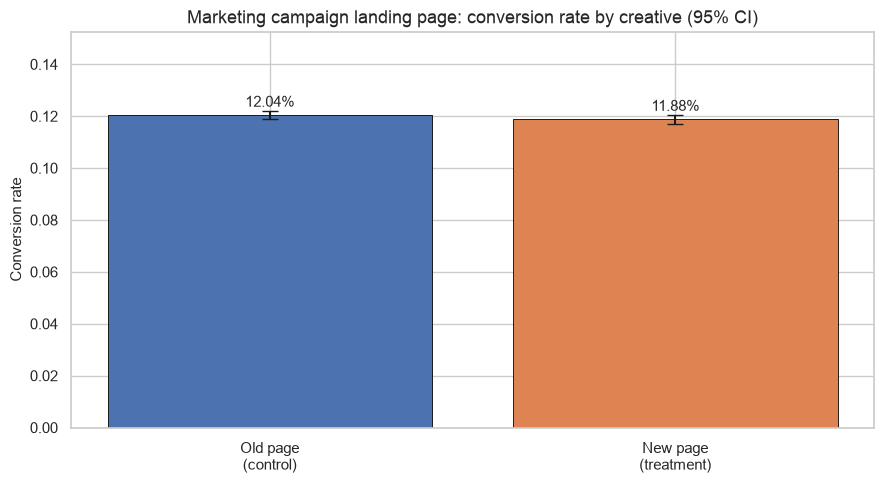

95% CI control:   [0.118713, 0.122060]
95% CI treatment: [0.117144, 0.120472]


In [6]:
# Bar chart with 95% CI error bars (normal approx via statsmodels proportion_confint)
ci_low_c, ci_high_c = proportion_confint(conv_control, n_control, alpha=0.05, method="normal")
ci_low_t, ci_high_t = proportion_confint(conv_treatment, n_treatment, alpha=0.05, method="normal")

plot_df = pd.DataFrame(
    {
        "creative": ["Old page\n(control)", "New page\n(treatment)"],
        "rate": [p_control, p_treatment],
        "ci_low": [ci_low_c, ci_low_t],
        "ci_high": [ci_high_c, ci_high_t],
    }
)
plot_df["yerr_low"] = plot_df["rate"] - plot_df["ci_low"]
plot_df["yerr_high"] = plot_df["ci_high"] - plot_df["rate"]

fig, ax = plt.subplots()
bars = ax.bar(
    plot_df["creative"],
    plot_df["rate"],
    yerr=[plot_df["yerr_low"], plot_df["yerr_high"]],
    capsize=6,
    color=["#4C72B0", "#DD8452"],
    edgecolor="black",
    linewidth=0.6,
)
ax.set_ylabel("Conversion rate")
ax.set_title("Marketing campaign landing page: conversion rate by creative (95% CI)")
ax.set_ylim(0, max(plot_df["ci_high"]) * 1.25)
for bar, rate in zip(bars, plot_df["rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{rate:.2%}",
        ha="center",
        va="bottom",
        fontsize=11,
    )
plt.tight_layout()
plt.show()

print("95% CI control:   [{:.6f}, {:.6f}]".format(ci_low_c, ci_high_c))
print("95% CI treatment: [{:.6f}, {:.6f}]".format(ci_low_t, ci_high_t))

### Conversion over time (novelty / drift check)

If the new creative only “wins” on day 1 and then fades, shipping on an early snapshot would be wrong. Conversely, a stable gap (or stable near-zero gap) over many days is more trustworthy. This dataset spans multiple days, so we plot **daily conversion rate by group**.

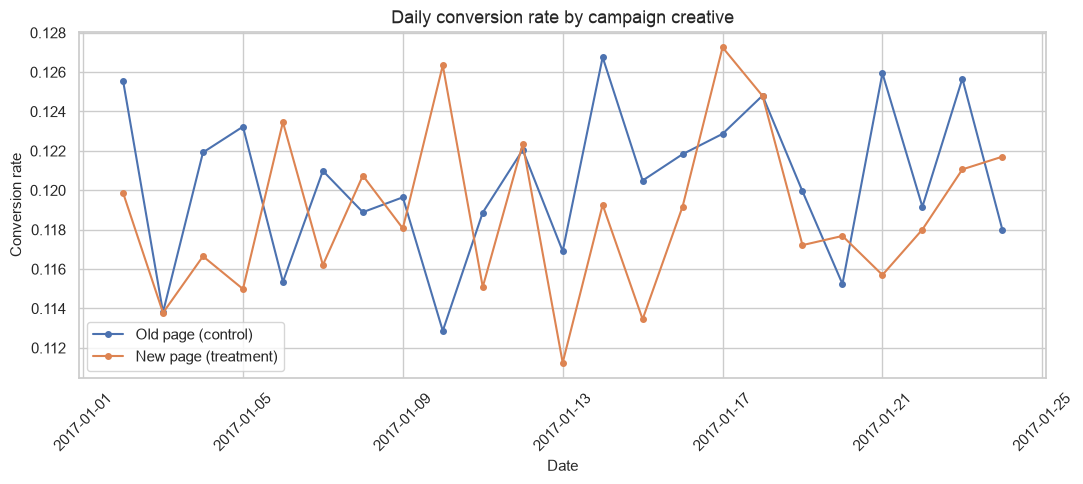

Experiment date range: 2017-01-02 13:42:05.378582 → 2017-01-24 13:41:54.460509
Number of distinct days: 23

Daily n by group (first/last 3 days):


group,control,treatment
date,,
2017-01-02,2859,2853
2017-01-03,6590,6618
2017-01-04,6578,6541
2017-01-22,6596,6669
2017-01-23,6716,6633
2017-01-24,3754,3681


In [7]:
ab_clean["timestamp"] = pd.to_datetime(ab_clean["timestamp"])
ab_clean["date"] = ab_clean["timestamp"].dt.date

daily = (
    ab_clean.groupby(["date", "group"], observed=True)["converted"]
    .agg(n="size", rate="mean")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
for group, color, label in [
    ("control", "#4C72B0", "Old page (control)"),
    ("treatment", "#DD8452", "New page (treatment)"),
]:
    g = daily.loc[daily["group"] == group].sort_values("date")
    ax.plot(g["date"], g["rate"], marker="o", markersize=4, color=color, label=label)

ax.set_title("Daily conversion rate by campaign creative")
ax.set_xlabel("Date")
ax.set_ylabel("Conversion rate")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print("Experiment date range:", ab_clean["timestamp"].min(), "→", ab_clean["timestamp"].max())
print("Number of distinct days:", ab_clean["date"].nunique())
print()
print("Daily n by group (first/last 3 days):")
daily_n = (
    ab_clean.groupby(["date", "group"], observed=True).size().unstack("group").sort_index()
)
display(pd.concat([daily_n.head(3), daily_n.tail(3)]))

### Country breakdown

We merge country and check whether conversion differs by market. Later, logistic regression will ask whether the page effect survives after adjusting for country.

Rows before country merge: 290,584
Rows after inner merge with countries: 290,584
Rows lost in merge: 0



Conversion by country (pooled arms):


,country,n,rate,rate_pct
0,CA,14499,0.115318,11.5318
1,UK,72466,0.120594,12.0594
2,US,203619,0.119547,11.9547


Conversion by country × group:


,country,group,n,rate,rate_pct
0,CA,control,7198,0.118783,11.8783
1,CA,treatment,7301,0.111902,11.1902
2,UK,control,36360,0.120022,12.0022
3,UK,treatment,36106,0.121171,12.1171
4,US,control,101716,0.120630,12.0630
5,US,treatment,101903,0.118466,11.8466


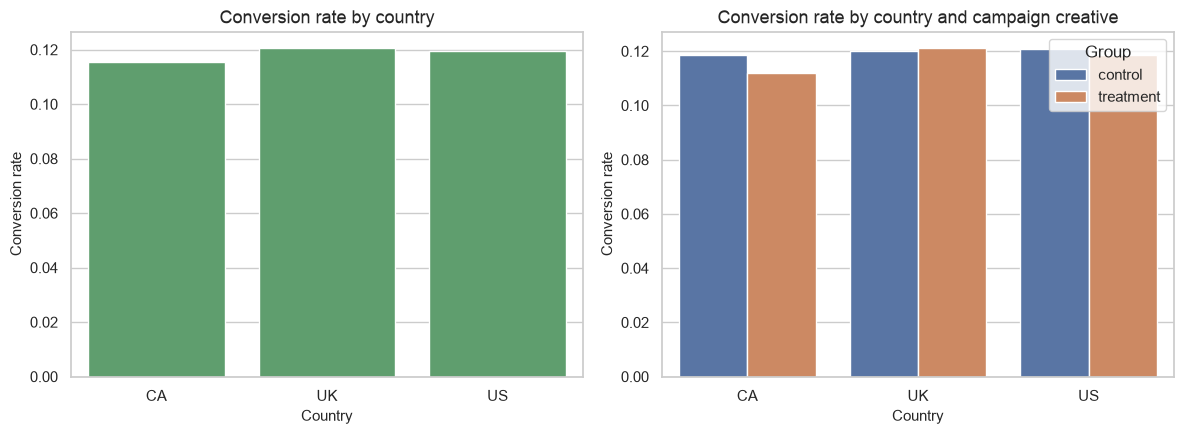

ab_page value counts (1 = new campaign creative):
ab_page
0    145274
1    145310
Name: count, dtype: int64


In [8]:
n_before_merge = len(ab_clean)
df = ab_clean.merge(countries, on="user_id", how="inner")
n_after_merge = len(df)
print(f"Rows before country merge: {n_before_merge:,}")
print(f"Rows after inner merge with countries: {n_after_merge:,}")
print(f"Rows lost in merge: {n_before_merge - n_after_merge:,}")

by_country = (
    df.groupby("country", observed=True)
    .agg(n=("converted", "size"), rate=("converted", "mean"))
    .reset_index()
    .sort_values("country")
)
by_country_group = (
    df.groupby(["country", "group"], observed=True)
    .agg(n=("converted", "size"), rate=("converted", "mean"))
    .reset_index()
)

print()
print("Conversion by country (pooled arms):")
display(by_country.assign(rate_pct=lambda d: (d["rate"] * 100).round(4)))
print("Conversion by country × group:")
display(by_country_group.assign(rate_pct=lambda d: (d["rate"] * 100).round(4)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=by_country, x="country", y="rate", ax=axes[0], color="#55A868")
axes[0].set_title("Conversion rate by country")
axes[0].set_ylabel("Conversion rate")
axes[0].set_xlabel("Country")

sns.barplot(data=by_country_group, x="country", y="rate", hue="group", ax=axes[1])
axes[1].set_title("Conversion rate by country and campaign creative")
axes[1].set_ylabel("Conversion rate")
axes[1].set_xlabel("Country")
axes[1].legend(title="Group")
plt.tight_layout()
plt.show()

# Dummy for regression later: 1 = new page / treatment
df["ab_page"] = (df["group"] == "treatment").astype(int)
print("ab_page value counts (1 = new campaign creative):")
print(df["ab_page"].value_counts().sort_index())

### EDA interpretation (using the numbers above)

Look at the printed rates: both creatives convert near the same overall level (~12%). The **new** campaign landing page is typically *slightly lower*, not higher — but we must not ship/kill on a raw difference alone. Sampling noise can create small gaps even when the true lift is zero.

Daily curves should sit on top of each other if there is no real effect (and no strong novelty pattern). Country bars show whether baseline conversion differs by market; large country main effects would motivate adjusting for country in Part 4 even if the page effect is stable.

## Part 3 — Hypothesis test (two-proportion z-test)

### In plain language

- **Null hypothesis (H0):** The new campaign landing page converts the same as the old one. Shipping the new creative would not change conversion.
- **Alternative (H1):** The two creatives convert at *different* rates (two-sided).

Why two-sided? Marketing often *hopes* the new page is better, but a honest test also allows “new page is worse.” One-sided tests that only look for improvement are easier to abuse after seeing the data. We use **α = 0.05** and will not move that threshold after seeing the p-value.

### Formally

Let \(p_{\text{new}}\) be the true conversion probability for the new creative (treatment) and \(p_{\text{old}}\) for the old creative (control).

\[
H_0: p_{\text{new}} - p_{\text{old}} = 0
\qquad
H_1: p_{\text{new}} - p_{\text{old}} \neq 0
\]

With large \(n\) and conversion rates not near 0 or 1, the difference in sample proportions is approximately normal → **two-proportion z-test**.

In [9]:
# count / nobs order: [treatment, control] so z > 0 means new page higher conversion
count = np.array([conv_treatment, conv_control], dtype=float)
nobs = np.array([n_treatment, n_control], dtype=float)

zstat, pval = proportions_ztest(count, nobs, alternative="two-sided")

# 95% CI for (p_treatment - p_control)
ci_low, ci_high = confint_proportions_2indep(
    count1=conv_treatment,
    nobs1=n_treatment,
    count2=conv_control,
    nobs2=n_control,
    compare="diff",
    alpha=0.05,
)

print("=== Two-proportion z-test (treatment vs control) ===")
print(f"Treatment: {conv_treatment:,} / {n_treatment:,}  →  p_new = {p_treatment:.6f}")
print(f"Control:   {conv_control:,} / {n_control:,}  →  p_old = {p_control:.6f}")
print(f"Difference (p_new − p_old): {abs_diff:.6f}")
print()
print(f"z-statistic: {zstat:.6f}")
print(f"p-value (two-sided): {pval:.6f}")
print(f"95% CI for (p_new − p_old): [{ci_low:.6f}, {ci_high:.6f}]")
print()

alpha = 0.05
if pval < alpha:
    decision = "REJECT H0"
    plain = (
        "The difference in conversion between the new and old campaign creatives "
        "is statistically significant at α=0.05."
    )
else:
    decision = "FAIL TO REJECT H0"
    plain = (
        "We do **not** have statistically significant evidence at α=0.05 that the "
        "new campaign landing page converts differently from the old one."
    )

print(f"Decision at α={alpha}: {decision}")
print(plain)
print()
if ci_low <= 0 <= ci_high:
    print("The 95% CI for the difference includes 0 — consistent with no real lift (or a tiny one).")
else:
    print("The 95% CI for the difference excludes 0 — consistent with a nonzero difference.")

=== Two-proportion z-test (treatment vs control) ===
Treatment: 17,264 / 145,310  →  p_new = 0.118808
Control:   17,489 / 145,274  →  p_old = 0.120386
Difference (p_new − p_old): -0.001578

z-statistic: -1.310924
p-value (two-sided): 0.189883
95% CI for (p_new − p_old): [-0.003938, 0.000781]

Decision at α=0.05: FAIL TO REJECT H0
We do **not** have statistically significant evidence at α=0.05 that the new campaign landing page converts differently from the old one.

The 95% CI for the difference includes 0 — consistent with no real lift (or a tiny one).


### Interpreting the hypothesis test

Read the printed **z**, **p-value**, and **CI** carefully:

- If **p ≥ 0.05**, we do not claim the new creative “won” or “lost” in a statistical sense — the data are compatible with no difference (or a difference too small to pin down at this α).
- The **confidence interval** is often more useful to a marketer than a binary p-value: it shows a plausible range for the true lift (new − old). If that range is centered near zero and only a few tenths of a percentage point wide, the experiment was informative: it *ruled out large lifts*, even if it did not prove a tiny negative effect.
- We will **not** re-run a one-sided test or drop more data to chase significance.

## Part 4 — Logistic regression (effect size + country adjustment)

### Why logistic regression here?

The z-test answers “is the difference distinguishable from zero?” Logistic regression answers a related but usefully different set of questions:

1. What is the **odds ratio** for converting on the new creative vs the old one?
2. Does that page effect **change after adjusting for country**?
3. (Optional) Does the page effect **interact** with country?

This is **not** a predictive model. We do not report accuracy, ROC-AUC, or train/test splits. We report coefficients and **odds ratios** because ORs are easier to reason about than raw log-odds.

- `ab_page = 1` → new campaign landing page (treatment)
- `ab_page = 0` → old campaign landing page (control)

An odds ratio of 1.00 means identical odds of conversion. OR = 0.99 means ~1% lower odds on the new page, etc.

In [10]:
def odds_ratio_table(result) -> pd.DataFrame:
    """Build OR + 95% CI + p-value table from a statsmodels discrete result."""
    params = result.params
    conf = result.conf_int()
    conf.columns = ["ci_low_log", "ci_high_log"]
    out = pd.DataFrame(
        {
            "coef_log_odds": params,
            "OR": np.exp(params),
            "OR_ci_low": np.exp(conf["ci_low_log"]),
            "OR_ci_high": np.exp(conf["ci_high_log"]),
            "pvalue": result.pvalues,
        }
    )
    return out


# Model 1: page only
m1 = smf.logit("converted ~ ab_page", data=df).fit(disp=False)
print("=== Model 1: converted ~ ab_page ===")
print(m1.summary())
print()
print("Odds ratios (Model 1):")
or1 = odds_ratio_table(m1)
display(or1)

=== Model 1: converted ~ ab_page ===


                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290582
Method:                           MLE   Df Model:                            1
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:               8.077e-06
Time:                        22:19:40   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1899
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9888      0.008   -246.669      0.000      -2.005      -1.973
ab_page       -0.0150      0.011     -1.311      0.190      -0.037       0.007

Odds ratios (Model 1):


,coef_log_odds,OR,OR_ci_low,OR_ci_high,pvalue
Intercept,-1.988777,0.136863,0.134717,0.139043,0.000000
ab_page,-0.014989,0.985123,0.963291,1.007449,0.189886


In [11]:
# Model 2: page + country
m2 = smf.logit("converted ~ ab_page + C(country)", data=df).fit(disp=False)
print("=== Model 2: converted ~ ab_page + C(country) ===")
print(m2.summary())
print()
print("Odds ratios (Model 2):")
or2 = odds_ratio_table(m2)
display(or2)

=== Model 2: converted ~ ab_page + C(country) ===


                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290580
Method:                           MLE   Df Model:                            3
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:               2.323e-05
Time:                        22:19:42   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1760
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.0300      0.027    -76.249      0.000      -2.082      -1.978
C(country)[T.UK]     0.0506      0.028      1.784      0.074      -0.005       0.106
C(country)[T.US]     0.0408 

,coef_log_odds,OR,OR_ci_low,OR_ci_high,pvalue
Intercept,-2.030029,0.131332,0.124654,0.138367,0.000000
C(country)[T.UK],0.050640,1.051944,0.995003,1.112144,0.074500
C(country)[T.US],0.040757,1.041599,0.988138,1.097953,0.129501
ab_page,-0.014943,0.985168,0.963335,1.007495,0.191245


In [12]:
# Model 3: interaction — teaching check; primary adjusted estimate remains Model 2 if interaction is weak
m3 = smf.logit("converted ~ ab_page * C(country)", data=df).fit(disp=False)
print("=== Model 3: converted ~ ab_page * C(country) ===")
print(m3.summary())
print()
print("Odds ratios (Model 3):")
or3 = odds_ratio_table(m3)
display(or3)

# Highlight ab_page across models
ab_page_compare = pd.DataFrame(
    {
        "model": ["ab_page only", "ab_page + country", "ab_page × country (main effect of ab_page)"],
        "OR_ab_page": [
            float(or1.loc["ab_page", "OR"]),
            float(or2.loc["ab_page", "OR"]),
            float(or3.loc["ab_page", "OR"]),
        ],
        "pvalue_ab_page": [
            float(or1.loc["ab_page", "pvalue"]),
            float(or2.loc["ab_page", "pvalue"]),
            float(or3.loc["ab_page", "pvalue"]),
        ],
    }
)
print("ab_page odds ratio across models:")
display(ab_page_compare)

or_ab_m1 = float(or1.loc["ab_page", "OR"])
or_ab_m2 = float(or2.loc["ab_page", "OR"])
pval_ab_m2 = float(or2.loc["ab_page", "pvalue"])

# Interaction term p-values (any term containing ':')
interaction_terms = [t for t in or3.index if ":" in t]
if interaction_terms:
    print()
    print("Interaction term p-values:")
    display(or3.loc[interaction_terms, ["OR", "OR_ci_low", "OR_ci_high", "pvalue"]])
    max_inter_p = float(or3.loc[interaction_terms, "pvalue"].min())
    print(
        f"Smallest interaction p-value: {max_inter_p:.4f} "
        f"({'suggests possible heterogeneity' if max_inter_p < 0.05 else 'no strong evidence of country×page interaction at α=0.05'})"
    )

=== Model 3: converted ~ ab_page * C(country) ===


                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290578
Method:                           MLE   Df Model:                            5
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:               3.482e-05
Time:                        22:19:45   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1920
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -2.0040      0.036    -55.008      0.000      -2.075      -1.933
C(country)[T.UK]             0.0118      0.040      0.296      0.767      -0.066       0.

,coef_log_odds,OR,OR_ci_low,OR_ci_high,pvalue
Intercept,-2.004006,0.134794,0.125505,0.144771,0.000000
C(country)[T.UK],0.011784,1.011854,0.935839,1.094042,0.767429
C(country)[T.US],0.017528,1.017682,0.945230,1.095689,0.641822
ab_page,-0.067448,0.934776,0.844176,1.035099,0.194724
ab_page:C(country)[T.UK],0.078282,1.081428,0.967501,1.208770,0.168119
ab_page:C(country)[T.US],0.046885,1.048001,0.943160,1.164496,0.383311


ab_page odds ratio across models:


,model,OR_ab_page,pvalue_ab_page
0,ab_page only,0.985123,0.189886
1,ab_page + country,0.985168,0.191245
2,ab_page × country (main effect of ab_page),0.934776,0.194724



Interaction term p-values:


,OR,OR_ci_low,OR_ci_high,pvalue
ab_page:C(country)[T.UK],1.081428,0.967501,1.208770,0.168119
ab_page:C(country)[T.US],1.048001,0.943160,1.164496,0.383311


Smallest interaction p-value: 0.1681 (no strong evidence of country×page interaction at α=0.05)


### Logistic regression interpretation

Focus on the **`ab_page` odds ratio**:

- Values **near 1.0** with a confidence interval covering 1.0 mean the new creative does not meaningfully change conversion odds.
- Adjusting for country (Model 2) checks whether market mix was confounding the raw comparison. If the OR barely moves after adding country, the page effect is **not** an artifact of country imbalance.
- Interaction terms (Model 3) ask whether the page effect differs by country. If those terms are non-significant, Model 2 is the cleaner summary for a manager: one average page effect, holding country fixed.

Again: no accuracy metrics. Odds ratios and p-values are the right summaries for this design.

## Part 5 — Statistical power and sample-size sanity check

A non-significant result can mean either:

1. The true effect is tiny / zero, **or**
2. The experiment was underpowered (too few users) to detect a real effect.

With ~145k users per arm, (2) is unlikely for modest lifts — but we should **compute** it, not assume.

We answer two numerical questions:

1. Given the **observed** difference, how large a sample would we need for 80% power at α=0.05?
2. For a **business-relevant minimum detectable effect (MDE)** of +1 percentage point absolute on the control baseline, what \(n\) per arm is needed — and what power did we actually have for that MDE?

If observed effect is tiny and \(n\) is already huge, **extending the experiment** is usually the wrong response. You already know the lift is not large.

In [13]:
# Observed effect size (Cohen's h) and required n for that effect
es_obs = proportion_effectsize(p_treatment, p_control)
# solve_power needs nonzero effect; if difference is exactly 0, note separately
if abs(es_obs) < 1e-12:
    n_for_obs = np.inf
    print("Observed effect size is ~0; infinite n would be needed to 'detect' a zero effect.")
else:
    n_for_obs = NormalIndPower().solve_power(
        effect_size=abs(es_obs),
        alpha=0.05,
        power=0.8,
        ratio=1.0,
        alternative="two-sided",
    )

# Power of the actual experiment for the observed difference
pwr_obs = power_proportions_2indep(
    diff=p_treatment - p_control,
    prop2=p_control,
    nobs1=n_treatment,
    ratio=n_control / n_treatment,
    alpha=0.05,
    alternative="two-sided",
    return_results=True,
)

# Business MDE: +1 percentage point absolute improvement over control
mde_pp = 0.01
p_mde = p_control + mde_pp
es_mde = proportion_effectsize(p_mde, p_control)
n_for_mde = NormalIndPower().solve_power(
    effect_size=es_mde,
    alpha=0.05,
    power=0.8,
    ratio=1.0,
    alternative="two-sided",
)
pwr_mde = power_proportions_2indep(
    diff=mde_pp,
    prop2=p_control,
    nobs1=n_treatment,
    ratio=n_control / n_treatment,
    alpha=0.05,
    alternative="two-sided",
    return_results=True,
)

actual_n_per_arm = min(n_control, n_treatment)

print("=== Observed effect ===")
print(f"p_new − p_old = {abs_diff:.6f}  ({abs_diff * 100:.4f} pp)")
print(f"Cohen's h (proportion_effectsize): {es_obs:.6f}")
print(f"n per arm needed for 80% power to detect the *observed* effect: {n_for_obs:,.0f}")
print(f"Actual n (control / treatment): {n_control:,} / {n_treatment:,}")
print(f"Achieved power for the observed difference at actual n: {pwr_obs.power:.4f}")
print()
print("=== Business MDE: +1.00 percentage point absolute ===")
print(f"Target rates: p_old={p_control:.6f}, p_new_target={p_mde:.6f}")
print(f"Cohen's h for MDE: {es_mde:.6f}")
print(f"n per arm needed for 80% power at this MDE: {n_for_mde:,.0f}")
print(f"Actual min arm size: {actual_n_per_arm:,}")
print(f"Achieved power for +1 pp MDE at actual n: {pwr_mde.power:.4f}")
print()

if actual_n_per_arm >= n_for_mde:
    power_story = (
        f"This experiment is **well powered** for a +1 pp absolute lift "
        f"(needed ~{n_for_mde:,.0f}/arm, we have ~{actual_n_per_arm:,}/arm; "
        f"power≈{pwr_mde.power:.1%}). A non-significant, near-zero observed effect "
        "is therefore evidence against a *business-meaningful* improvement — "
        "not a signal to run forever."
    )
else:
    power_story = (
        f"Sample may be short of 80% power for a +1 pp MDE "
        f"(needed ~{n_for_mde:,.0f}/arm vs actual ~{actual_n_per_arm:,}/arm). "
        "Extending could be justified only if stakeholders pre-commit to that MDE."
    )
print(power_story)

=== Observed effect ===
p_new − p_old = -0.001578  (-0.1578 pp)
Cohen's h (proportion_effectsize): -0.004864
n per arm needed for 80% power to detect the *observed* effect: 663,574
Actual n (control / treatment): 145,274 / 145,310
Achieved power for the observed difference at actual n: 0.2587

=== Business MDE: +1.00 percentage point absolute ===
Target rates: p_old=0.120386, p_new_target=0.130386
Cohen's h for MDE: 0.030203
n per arm needed for 80% power at this MDE: 17,209
Actual min arm size: 145,274
Achieved power for +1 pp MDE at actual n: 1.0000

This experiment is **well powered** for a +1 pp absolute lift (needed ~17,209/arm, we have ~145,274/arm; power≈100.0%). A non-significant, near-zero observed effect is therefore evidence against a *business-meaningful* improvement — not a signal to run forever.


### Power takeaway for “should we extend?”

- Detecting an effect as **small as the one we observed** would require an enormous sample (printed above) — that is the math saying “this lift is tiny.”
- Detecting a **+1 percentage point** improvement is a realistic marketing bar. If our actual \(n\) already exceeds the 80%-power requirement for that MDE, then **extending the test is not the right next step**. The data already say a meaningful win is unlikely.
- Extend only if the business cares about even smaller lifts *and* is willing to pay for the huge \(n\) those lifts demand.

## Conclusion — explaining this to your marketing manager

The code cell below prints a manager-ready summary with the **actual numbers** from this run. The recommendation is one of: **SHIP**, **HOLD**, or **EXTEND**.

In [14]:
# Decision logic (transparent, not post-hoc α shopping)
significant = pval < 0.05
improved = abs_diff > 0
# "business meaningful" threshold: at least +0.5 pp absolute and significant
meaningful_lift = significant and abs_diff >= 0.005
underpowered_for_mde = pwr_mde.power < 0.8

if meaningful_lift:
    recommendation = "SHIP"
    rec_reason = (
        "Statistically significant improvement of at least +0.5 pp absolute for the new creative."
    )
elif significant and not improved:
    recommendation = "HOLD"
    rec_reason = (
        "New creative is statistically significantly *worse* (or lower) than the old creative; do not ship."
    )
elif underpowered_for_mde:
    recommendation = "EXTEND"
    rec_reason = (
        "Result is non-significant and the experiment is underpowered for a +1 pp MDE; more data could still resolve a meaningful lift."
    )
else:
    recommendation = "HOLD"
    rec_reason = (
        "No statistically significant improvement; sample is already large enough that a business-meaningful "
        "lift (+1 pp) would likely have been detected. Keep the old campaign creative."
    )

print("=" * 72)
print("MARKETING MANAGER SUMMARY")
print("=" * 72)
print()
print("Experiment: two creatives of a marketing campaign landing page (old vs new).")
print(f"Data source path: {load_path_used.splitlines()[0]}")
print()
print("Data cleaning")
print(f"  Raw rows:                      {n_before:,}")
print(f"  Mismatched group/page rows:    {n_mismatch:,}  (dropped)")
print(f"  After mismatch drop:           {n_after_mismatch:,}")
print(f"  After de-duplicate user_id:    {n_after_dedup:,}")
print(f"  After country merge (models):  {n_after_merge:,}")
print()
print("Conversion rates (cleaned A/B sample)")
print(f"  Old page (control):   {p_control:.4%}   n={n_control:,}")
print(f"  New page (treatment): {p_treatment:.4%}   n={n_treatment:,}")
print(f"  Difference (new−old): {abs_diff:+.4%} absolute  ({rel_diff:+.2%} relative)")
print()
print("Two-proportion z-test (α=0.05, two-sided)")
print(f"  z = {zstat:.4f}")
print(f"  p = {pval:.6f}   →  {decision}")
print(f"  95% CI for (p_new − p_old): [{ci_low:.6f}, {ci_high:.6f}]")
print()
print("Logistic regression odds ratio for new page (ab_page)")
print(f"  Unadjusted OR:          {or_ab_m1:.4f}")
print(f"  Country-adjusted OR:    {or_ab_m2:.4f}   (p={pval_ab_m2:.6f})")
print()
print("Power / sample size")
print(f"  n/arm for 80% power @ observed effect: {n_for_obs:,.0f}")
print(f"  n/arm for 80% power @ +1 pp MDE:       {n_for_mde:,.0f}")
print(f"  Actual min arm n:                      {actual_n_per_arm:,}")
print(f"  Power for +1 pp MDE at actual n:       {pwr_mde.power:.1%}")
print()
print(f"RECOMMENDATION: {recommendation}")
print(f"  Reason: {rec_reason}")
print()
print("Plain-language brief:")
if recommendation == "EXTEND":
    brief = (
        f"  We tested a new marketing-campaign landing page against the current one on "
        f"{n_after_dedup:,} cleaned unique users. Conversion was {p_control:.2%} on the old page and "
        f"{p_treatment:.2%} on the new page. Results were not decisive for a business-sized lift; "
        f"**Decision: EXTEND** the experiment with a pre-registered MDE."
    )
elif recommendation == "SHIP":
    brief = (
        f"  We tested a new marketing-campaign landing page against the current one on "
        f"{n_after_dedup:,} cleaned unique users. Conversion was {p_control:.2%} on the old page and "
        f"{p_treatment:.2%} on the new page (difference {abs_diff * 100:+.3f} pp). "
        f"The two-proportion z-test gave z={zstat:.2f}, p={pval:.3f} — significant at α=0.05. "
        f"The country-adjusted odds ratio for the new page is {or_ab_m2:.3f}. "
        f"**Decision: SHIP** the new campaign creative."
    )
else:
    brief = (
        f"  We tested a new marketing-campaign landing page against the current one on "
        f"{n_after_dedup:,} cleaned unique users. Conversion was {p_control:.2%} on the old page and "
        f"{p_treatment:.2%} on the new page (difference {abs_diff * 100:+.3f} pp). "
        f"The two-proportion z-test gave z={zstat:.2f}, p={pval:.3f} — "
        f"{'significant' if significant else 'not significant'} at α=0.05. "
        f"The country-adjusted odds ratio for the new page is {or_ab_m2:.3f} "
        f"(values near 1.0 mean little change in conversion odds). "
        f"With ~{actual_n_per_arm:,} users per arm we were well positioned to detect a +1 pp lift "
        f"(power ≈ {pwr_mde.power:.0%}). "
        f"**Decision: HOLD** the old campaign creative — do not ship the new page."
    )
print(brief)
print()
print("Limitations:")
print("  - Mismatched assignment/page rows were dropped (unobservable true exposure).")
print("  - One row kept per user_id after duplicates.")
print("  - Country is a covariate, not a re-randomized factor.")
print("  - No pre-registered MDE in the public dataset; +1 pp used as a transparent business benchmark.")
print("  - Two-sided test; we did not re-specify α or models after seeing results.")
print("=" * 72)

MARKETING MANAGER SUMMARY

Experiment: two creatives of a marketing campaign landing page (old vs new).
Data source path: raw GitHub URLs

Data cleaning
  Raw rows:                      294,478
  Mismatched group/page rows:    3,893  (dropped)
  After mismatch drop:           290,585
  After de-duplicate user_id:    290,584
  After country merge (models):  290,584

Conversion rates (cleaned A/B sample)
  Old page (control):   12.0386%   n=145,274
  New page (treatment): 11.8808%   n=145,310
  Difference (new−old): -0.1578% absolute  (-1.31% relative)

Two-proportion z-test (α=0.05, two-sided)
  z = -1.3109
  p = 0.189883   →  FAIL TO REJECT H0
  95% CI for (p_new − p_old): [-0.003938, 0.000781]

Logistic regression odds ratio for new page (ab_page)
  Unadjusted OR:          0.9851
  Country-adjusted OR:    0.9852   (p=0.191245)

Power / sample size
  n/arm for 80% power @ observed effect: 663,574
  n/arm for 80% power @ +1 pp MDE:       17,209
  Actual min arm n:                      1

### Final framing

| Question | Answer from this notebook |
|---|---|
| Did we clean the data properly? | Yes — mismatches and duplicate users handled with before/after counts. |
| Is the new creative statistically better? | See p-value and CI above (α=0.05). |
| Is any difference large enough to care about? | Compare absolute pp lift and the OR near/far from 1.0. |
| Should we run longer? | Only if underpowered for a pre-agreed MDE — see Part 5 numbers. |
| Ship / hold / extend? | Printed recommendation in the summary cell. |

**Remember:** a large, clean experiment that finds ~zero lift is a *successful* experiment. It stops the company from shipping a worse (or equal) marketing campaign creative on gut feel.